# **IMPORT LIBRARIES**

In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import seaborn as sns
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

# **LOAD DATASET**

In [32]:
Customer_Churn = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", Customer_Churn.shape)
print(Customer_Churn.head())

Dataset Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

# **SUMMARY STATISTICS**

In [33]:
print("===== SUMMARY STATISTICS =====")
print(Customer_Churn.describe())

===== SUMMARY STATISTICS =====
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [34]:
print("\n===== MISSING VALUES =====")
print(Customer_Churn.isnull().sum())


===== MISSING VALUES =====
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# **EDA VISUALIZATIONS**

In [35]:
sns.set(style="whitegrid")

# **CHURN DISTRIBUTION**

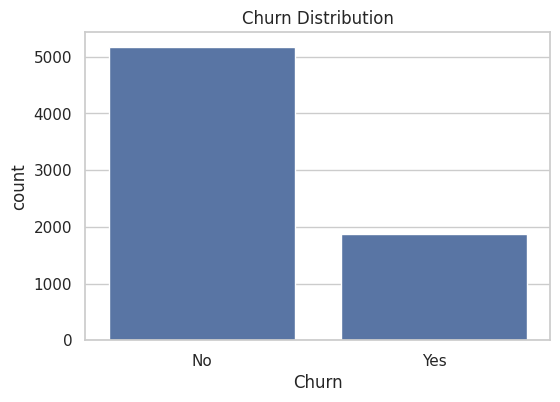

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=Customer_Churn)
plt.title("Churn Distribution")
plt.show()

# **CONTRACT TYPE vs CHURN**

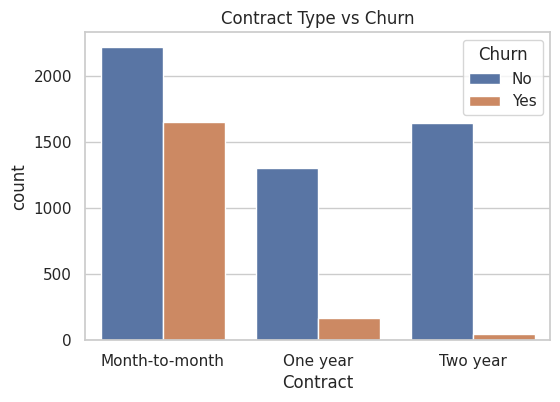

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x="Contract", hue="Churn", data=Customer_Churn)
plt.title("Contract Type vs Churn")
plt.show()

# **TENURE DISTRIBUTION**

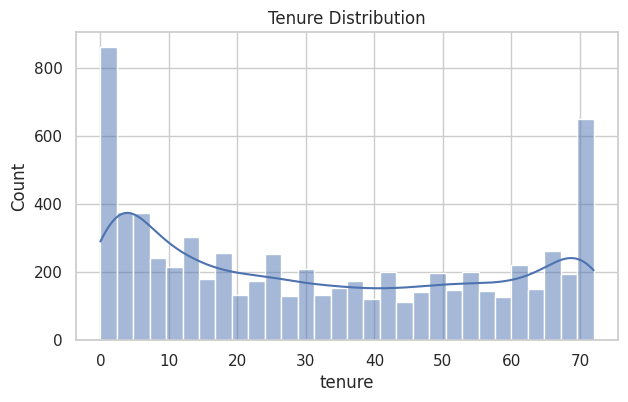

In [38]:
plt.figure(figsize=(7,4))
sns.histplot(Customer_Churn["tenure"], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.show()

# **MONTHLY CHARGES vs CHURN**

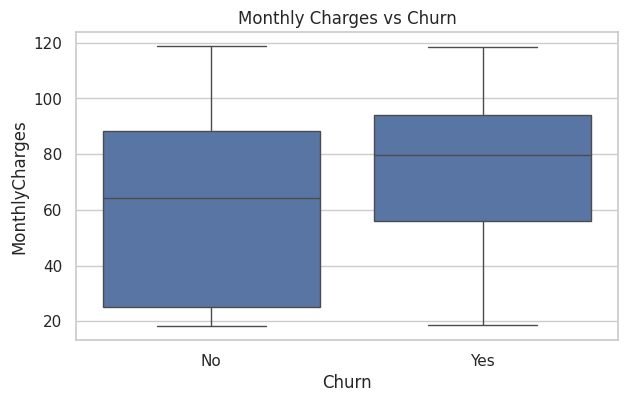

In [39]:
plt.figure(figsize=(7,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=Customer_Churn)
plt.title("Monthly Charges vs Churn")
plt.show()

# **INTERNET SERVICE IMPACT**

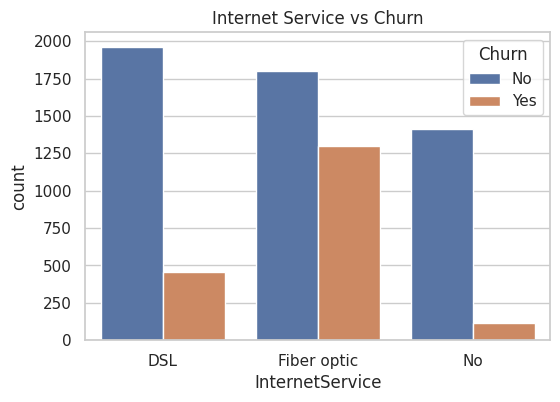

In [40]:
plt.figure(figsize=(6,4))
sns.countplot(x="InternetService", hue="Churn", data=Customer_Churn)
plt.title("Internet Service vs Churn")
plt.show()

# **DATA CLEANING**

In [41]:
# Remove customerID (not useful)
Customer_Churn.drop("customerID", axis=1, inplace=True)

In [42]:
# Convert TotalCharges to numeric
Customer_Churn["TotalCharges"] = pd.to_numeric(Customer_Churn["TotalCharges"], errors="coerce")

In [43]:
# Fill missing values
Customer_Churn["TotalCharges"].fillna(Customer_Churn["TotalCharges"].median(), inplace=True)

# **LABEL ENCODING**

In [44]:
le = LabelEncoder()

for column in Customer_Churn.columns:
    if Customer_Churn[column].dtype == "object":
        Customer_Churn[column] = le.fit_transform(Customer_Churn[column])

print(Customer_Churn.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 

# **SPLIT DATA**

In [45]:
X = Customer_Churn.drop("Churn", axis=1)
y = Customer_Churn["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# **HANDLE CLASS IMBALANCE (SMOTE)**

In [46]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [47]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Churn
0    4138
1    1496
Name: count, dtype: int64
After SMOTE: Churn
0    4138
1    4138
Name: count, dtype: int64


# **MODEL TRAINING**

In [48]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

In [49]:
dt_pred = dt_model.predict(X_test)

In [50]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [51]:
rf_pred = rf_model.predict(X_test)

In [52]:
# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [53]:
xgb_pred = xgb_model.predict(X_test)

# **MODEL EVALUATION**

In [54]:
print("\n===== DECISION TREE =====")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))


===== DECISION TREE =====
Accuracy: 0.7260468417317246
[[817 219]
 [167 206]]
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1036
           1       0.48      0.55      0.52       373

    accuracy                           0.73      1409
   macro avg       0.66      0.67      0.66      1409
weighted avg       0.74      0.73      0.73      1409



In [55]:
print("\n===== RANDOM FOREST =====")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


===== RANDOM FOREST =====
Accuracy: 0.7750177430801988
[[877 159]
 [158 215]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.57      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [56]:
print("\n===== XGBOOST =====")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))


===== XGBOOST =====
Accuracy: 0.7714691270404542
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1036
           1       0.56      0.60      0.58       373

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



### Decision Tree Confusion Matrix

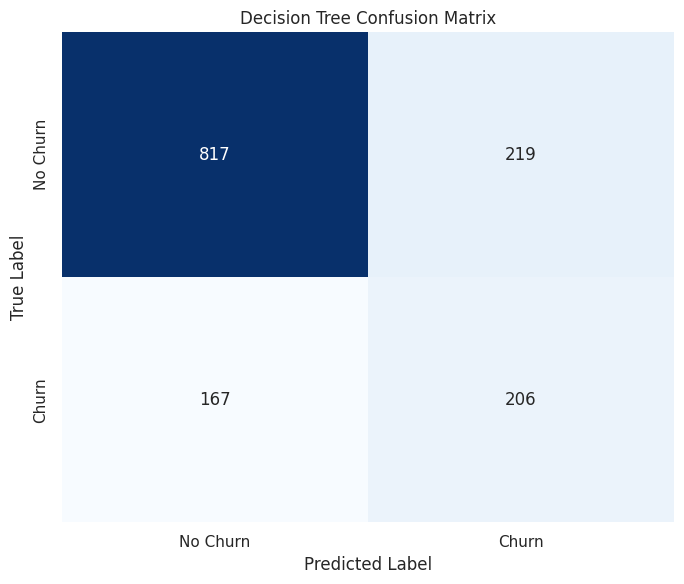

In [57]:
def plot_confusion_matrix(y_true, y_pred, title, ax, cmap):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

fig, ax = plt.subplots(figsize=(7, 6))
plot_confusion_matrix(y_test, dt_pred, 'Decision Tree Confusion Matrix', ax, 'Blues')
plt.tight_layout()
plt.show()

### Random Forest Confusion Matrix

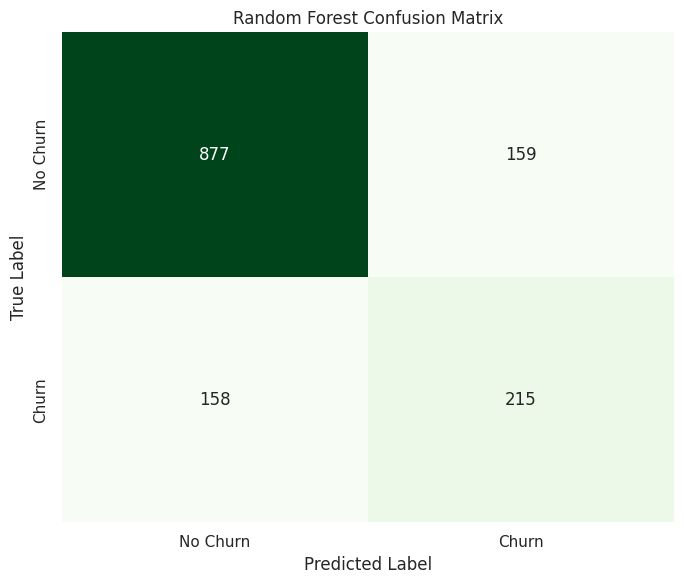

In [58]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_confusion_matrix(y_test, rf_pred, 'Random Forest Confusion Matrix', ax, 'Greens')
plt.tight_layout()
plt.show()

### XGBoost Confusion Matrix

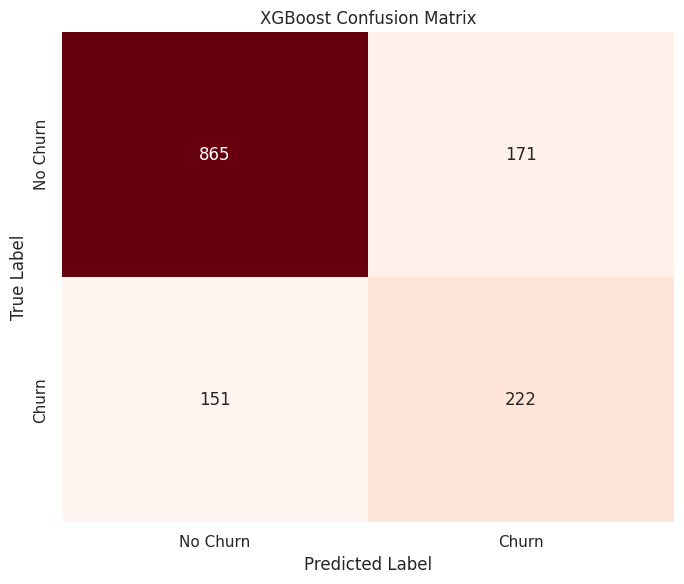

In [59]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_confusion_matrix(y_test, xgb_pred, 'XGBoost Confusion Matrix', ax, 'Reds')
plt.tight_layout()
plt.show()

# **FEATURE IMPORTANCE (RF)**

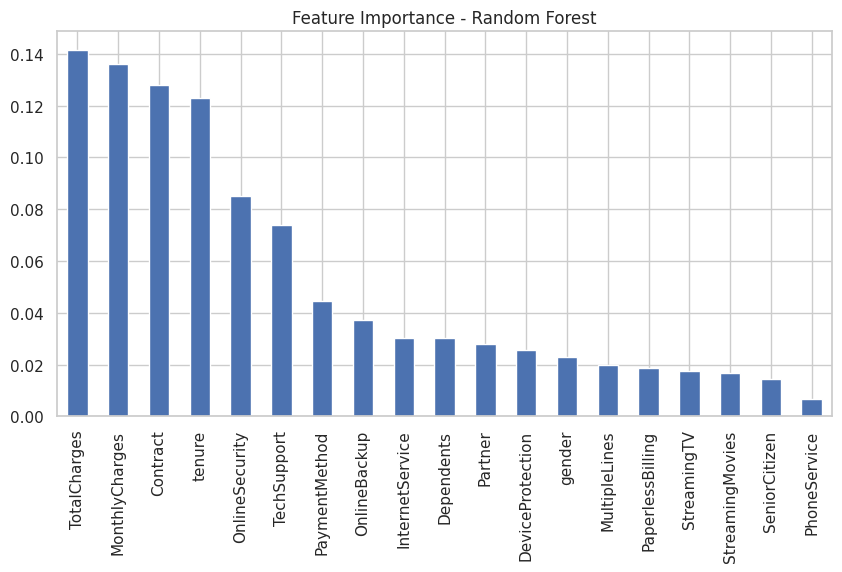

In [60]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))

plt.title("Feature Importance - Random Forest")
plt.show()